In [ ]:
# AND Gate 데이터로 학습
import numpy as np

x = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])
d = np.array([[0], [0], [0], [1]])

In [ ]:
def sigmoid(x):
    return 1. / (1. + np.exp(-x))

In [ ]:
# 결과 출력 함수
def calc_output(w, x):
    v = np.matmul(w, x)
    y = sigmoid(v)

    return y

In [ ]:
# 미분을 통해 오차의 기울기를 계산하는 함수
# Sigmoid 함수의 미분 = Sigmoid * (1 - Sigmoid)
def calc_error(d, y):
    e = d - y
    delta = y * (1 - y) * e

    return delta

In [ ]:
# 오차의 기울기를 통해 가중치를 갱신하는 함수
# 경사하강법 (Gradient Descent)
def delta_GD(w, x, d, lr):
    for k in range(4):
        x_ = x[k, :].T
        d_ = d[k]

        y = calc_output(w, x_)
        delta = calc_error(d_, y)

        dw = lr * delta * x_
        w = w + dw

    return w, delta

In [ ]:
w = 2 * np.random.random((1, 3)) - 1
lr = 0.9

hist_w = []
hist_delta = []

for epoch in range(1000):
    w, delta = delta_GD(w, x, d, lr)

    hist_w.append(w)
    hist_delta.append(delta)

    if epoch % 100 == 0:
        print(w) # [[w1, w2, b]]

[[-0.38665212  0.3727677  -0.43444997]]
[[ 2.6302097   2.5964556  -3.98097513]]
[[ 3.45883724  3.43974104 -5.24858738]]
[[ 3.95368654  3.94093598 -6.00106259]]
[[ 4.30283543  4.29336335 -6.52987307]]
[[ 4.57113725  4.56363795 -6.93526386]]
[[ 4.78833308  4.78214296 -7.26292479]]
[[ 4.97042871  4.96516748 -7.53733578]]
[[ 5.1269885   5.12241901 -7.77307821]]
[[ 5.26416768  5.26013248 -7.97951361]]


In [ ]:
np.array(hist_w).reshape(-1, 3)

array([[-0.38665212,  0.3727677 , -0.43444997],
       [-0.30125413,  0.40148875, -0.53718949],
       [-0.21521732,  0.43482582, -0.62786467],
       ...,
       [ 5.38268398,  5.37906195, -8.15778108],
       [ 5.38384159,  5.38022339, -8.15952196],
       [ 5.38499797,  5.3813836 , -8.16126099]])

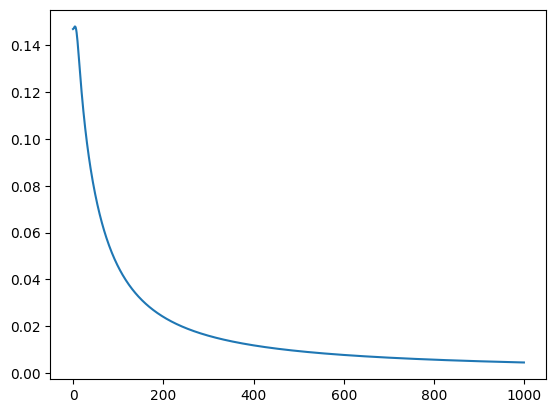

In [ ]:
# epoch 당 loss의 변화
# 0에 수렴하는 것을 볼 수 있음
import matplotlib.pyplot as plt

plt.plot(hist_delta)
plt.show()

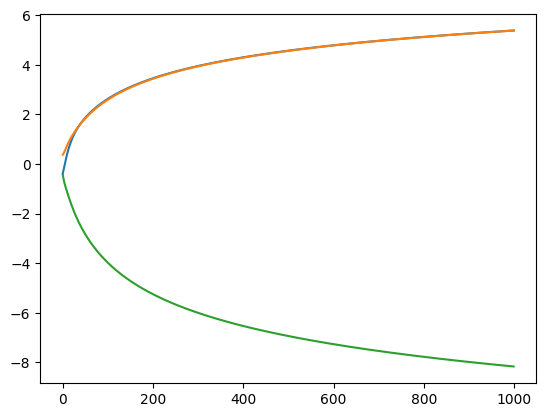

In [ ]:
# 가중치 w1, w2와 바이어스 b의 변화
# 둘다 잘 수렴하는 것을 볼 수 있음
plt.plot(np.array(hist_w).reshape(-1, 3))
plt.show()

In [ ]:
# 결과 (0, 0, 0, 1)
for k in range(4):
    x_ = x[k, :].T
    y = calc_output(w, x_)
    print(y)

[0.00028542]
[0.0584213]
[0.05862044]
[0.93119041]


In [ ]:
# 편미분과 역전파를 사용하여 XOR 학습
x = np.array([[0, 0, 1],
              [0, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

d = np.array([[0], [1], [1], [0]])

w1 = 2 * np.random.random((4, 3)) - 1
w2 = 2 * np.random.random((1, 4)) - 1

In [ ]:
# XOR은 2개의 층이 필요함
def calc_output(w1, w2, x):       # (4, 3), (1, 4), (3,)
    v1 = np.matmul(w1, x)         # (4, 3) @ (3,) = (4,)
    y1 = sigmoid(v1)              # (4,)

    v = np.matmul(w2, y1)         # (1, 4) @ (4,) = (1,)
    y = sigmoid(v)                # (1,)

    return y, y1                  # (1,), (4,)

def calc_delta(d, y):             # (1,), (1,)
    e = d - y                     # (1,) - (1,) = (1,)
    delta = y * (1 - y) * e       # (1,)

    return delta                  # (1,)

def calc_delta1(w2, delta, y1):   # (1, 4), (1,), (4,)
    e1 = np.matmul(w2.T, delta)   # (4,) @ (1,) = (4,)
    delta1 = y1 * (1 - y1) * e1   # (4,) * (4,) * (4,) = (4,)

    return delta1                 # (4,)

def backprop_XOR(w1, w2, x, d, lr):         # (4, 3), (1, 4), (4, 3), (4,)
    for k in range(4):
        x_ = x[k, :].T                      # (3,)
        d_ = d[k]                           # (1,)

        y, y1 = calc_output(w1, w2, x_)     # (1,), (4,)
        delta = calc_delta(d_, y)           # (1,)
        delta1 = calc_delta1(w2, delta, y1) # (4,)

        # (4,) * (1, 3) = (4, 3)
        dw1 = (lr * delta1).reshape(-1, 1) * x_.reshape(1, -1)
        w1 = w1 + dw1                       # (4, 3) + (4, 3) = (4, 3)

        dw2 = lr * delta * y1               # (1,) * (1, 4) = (1, 4)
        w2 = w2 + dw2                       # (1, 4) + (1, 4) = (1, 4)

    return w1, w2, delta                    # (4, 3), (1, 4), (1,)

In [ ]:
# 학습
lr = 0.9
for epoch in range(10000):
    w1, w2, delta = backprop_XOR(w1, w2, x, d, lr)

    if epoch % 1000 == 0:
        print(delta)

[-0.097195]
[-0.00438235]
[-0.00108419]
[-0.00058092]
[-0.00038866]
[-0.0002891]
[-0.00022881]
[-0.00018861]
[-0.00016]
[-0.00013866]


In [ ]:
# 결과 (0, 1, 1, 0)
for k in range(4):
    x_ = x[k, :].T
    y, y1 = calc_output(w1, w2, x_)
    print(y)

[0.01087106]
[0.9891631]
[0.98988276]
[0.01110776]
